# Advanced Model Analysis - Random Forest and XGBoost

This notebook extends the modelling analysis by implementing more flexible machine learning algorithms, **Random Forest** and **XGBoost**, to predict customer response to the monthly food basket subscription campaign. While logistic regression provides a useful baseline and interpretable benchmark, tree-based ensemble methods can capture non-linear relationships, complex feature interactions, and heterogeneous customer behaviour that linear models may miss.

The modelling strategy follows a structured evaluation framework:

1.	**A Random Forest Model** to capture non-linear patterns and interactions between customer characteristics while maintaining robustness through ensemble averaging.
2.	**An XGBoost Model**, a gradient boosting approach designed to iteratively correct prediction errors and produce highly accurate probability estimates.
3.	**Behavioural and Demographic Model Variants**, allowing us to assess whether campaign response is better explained by how customers behave or who the customers are.

Comparing these models allows us to evaluate improvements over the logistic regression baseline, assess the relative importance of behavioural versus demographic information, and identify the most effective modelling approach for targeting customers with the highest probability of responding to the campaign.


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier
from typing import cast


# Sklearn — preprocessing & splitting
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    RandomizedSearchCV, StratifiedKFold,
    learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import randint, uniform

# Sklearn — models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Sklearn — evaluation
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

In [2]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns


Dataset shape: 2236 rows × 30 columns

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

Using the previously defined feature sets, three input matrices are created: `X_full`, `X_behav`, and `X_demo`, corresponding to the full, behavioural, and demographic feature configurations. Categorical variables are converted into dummy variables where necessary. The target variable y corresponds to the campaign response indicator.

In [3]:
# Create copy of the dataframe for modeling
df_model = df.copy()

# Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]
df_model = df_model.drop(columns=cols_to_drop)

# Target
target = 'Response'

# Full Model: all available features
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

print(f"Full model: {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical features")


Full model: 11 numerical + 2 categorical features


In [4]:
X_full  = pd.concat([df_model[numerical_features_full],
                     pd.get_dummies(df_model[categorical_features_full],  drop_first=True)], axis=1)

y = df_model[target].copy()

print(f"\nX_full  shape : {X_full.shape}")
print(f"y       shape : {y.shape}  | Positive rate: {y.mean():.1%}")



X_full  shape : (2236, 20)
y       shape : (2236,)  | Positive rate: 14.9%


## 2. Train/Test Split

The dataset is split into training and test sets using an 80/20 split. Stratified sampling is applied to ensure that the proportion of positive responses remains similar in both subsets. This helps maintain the class distribution of the original dataset and provides a more reliable evaluation of model performance.

The same indices are used to create training and test splits for the full, behavioural, and demographic feature sets, ensuring that all models are evaluated on the exact same observations.

In [5]:
# Load the shared split indices produced in EDA.ipynb (Section 9)
idx_train = np.load('../data/idx_train.npy')
idx_test  = np.load('../data/idx_test.npy')

# Full model splits
X_train, X_test = X_full.iloc[idx_train], X_full.iloc[idx_test]
y_train = y.iloc[idx_train]
y_test  = y.iloc[idx_test]

print(f'Train size : {len(y_train):,} rows | Test size : {len(y_test):,} rows')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test  positive rate: {y_test.mean():.1%}')

Train size : 1,788 rows | Test size : 448 rows
Train positive rate: 14.9%
Test  positive rate: 15.0%


## 3. Full Model - Random Forest

The first advanced model is a Random Forest classifier trained on the full feature set, which includes both behavioural and demographic predictors. Random Forest is an ensemble method that combines multiple decision trees to capture non-linear relationships and interactions between variables.

Using the full set of features provides a comprehensive benchmark and allows us to evaluate how well the model performs when all available information about the customer is used.

### 3.1 Baseline Model before tuning

Before performing hyperparameter tuning, a baseline Random Forest model is trained using the default configuration. This provides a reference level of performance for comparison with the tuned model in section 3.3.

To address the class imbalance in the dataset, the parameter `class_weight='balanced'` is applied so that the minority class (customers who responded to the campaign) receives greater weight during training.

In [6]:
rf_default = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_default.fit(X_train, y_train)

y_pred_default  = rf_default.predict(X_test)
y_prob_default  = rf_default.predict_proba(X_test)[:, 1]

print(f"Default RF — ROC-AUC   : {roc_auc_score(y_test, y_prob_default):.4f}")
print(f"Default RF — Recall    : {recall_score(y_test, y_pred_default):.4f}")
print(f"Default RF — Precision : {precision_score(y_test, y_pred_default):.4f}")
print(f"Default RF — F1        : {f1_score(y_test, y_pred_default):.4f}")

Default RF — ROC-AUC   : 0.8636
Default RF — Recall    : 0.2836
Default RF — Precision : 0.6552
Default RF — F1        : 0.3958


### 3.2 Out-of-Bag (OOB) Score Evaluation

Random Forest models use bootstrap sampling when building individual trees. Observations that are not included in a given bootstrap sample are called **out-of-bag (OOB) observations**.

These observations can be used as an internal validation set to estimate model performance during training. The OOB score therefore provides a quick indication of how well the model generalises without requiring an additional validation split.

In [7]:
rf_oob = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

print(f"OOB Score (accuracy proxy): {rf_oob.oob_score_:.4f}")
print("Note: OOB uses ~1/3 of data excluded from each bootstrap sample.")
print("It serves as a built-in cross-validation estimate.")

OOB Score (accuracy proxy): 0.8814
Note: OOB uses ~1/3 of data excluded from each bootstrap sample.
It serves as a built-in cross-validation estimate.


### 3.3 Hyperparameter tuning via RandomizedSearchCV and GridSearchCV

To improve model performance, we tune key Random Forest hyperparameters using **RandomizedSearchCV**. This method samples different combinations of parameters from predefined distributions and evaluates them using stratified **5-fold cross-validation**.

We use **ROC-AUC** as the optimisation metric, since the goal is to distinguish between customers who respond to the campaign and those who do not. It evaluates the model's ability to rank customers by their likelihood to respond, without committing to a threshold yet and gives a clean picture of overall model quality.

In [8]:
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator  = RandomForestClassifier(
                     random_state=42,
                     class_weight='balanced',
                     n_jobs=1
                 ),
    param_distributions = param_dist,
    n_iter     = 50,
    cv         = cv_strategy,
    scoring    = 'roc_auc',
    random_state = 42,
    n_jobs     = 1,
    verbose    = 1
)

random_search.fit(X_train, y_train)

print(f"Best parameters : {random_search.best_params_}")
print(f"Best CV AUC     : {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 413}
Best CV AUC     : 0.8866


Based on the results from the RandomizedSearch we will now peform a more specific GridSearch around the best model parameters found so far.

In [9]:
from sklearn.model_selection import GridSearchCV

# Tighten around best_params from RandomizedSearchCV
rf_grid = {
    'n_estimators':      [150, 200, 300],
    'max_depth':         [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

rf_grid_search_r1 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1, verbose=1
)

rf_grid_search_r1.fit(X_train, y_train)

print(f"Best parameters : {rf_grid_search_r1.best_params_}")
print(f"Best CV AUC     : {rf_grid_search_r1.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV AUC     : 0.8882


In [10]:
from sklearn.model_selection import GridSearchCV

# Tighten around best_params from RandomizedSearchCV
rf_grid = {
    'n_estimators':      [175, 200, 225, 250],
    'max_depth':         [8, 9, 10, 11, 12],
    'min_samples_split': [8, 10, 12],
    'min_samples_leaf':  [1, 2],
}

rf_grid_search_r2 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1, verbose=1
)

rf_grid_search_r2.fit(X_train, y_train)

print(f"Best parameters : {rf_grid_search_r2.best_params_}")
print(f"Best CV AUC     : {rf_grid_search_r2.best_score_:.4f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters : {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 175}
Best CV AUC     : 0.8888


### 3.4 Tuning Progression & Best Parameter Selection

Three rounds of search progressively narrowed the parameter space. The table and chart below compare all rounds; the best parameters (highest CV AUC) are then used to rebuild `best_rf` for all subsequent evaluation.

=== Hyperparameter Tuning Progression — Random Forest ===
                                      n_estimators  max_depth  min_samples_split  min_samples_leaf  CV AUC
Round                                                                                                     
Round 1\nRandomizedSearch (50 iter)            413         20                 13                 1  0.8866
Round 1\nGridSearch (120 candidates)           200         10                 10                 1  0.8882
Round 2\nGridSearch (120 candidates)           175         12                  8                 2  0.8888


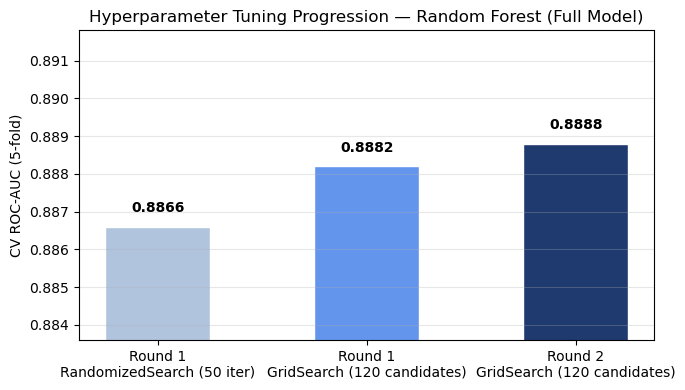


Final best parameters (Round 3): {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 175}
Best CV AUC : 0.8888
best_rf rebuilt with optimised parameters.


In [11]:
# Tuning Progression Summary
tuning_summary = [
    {
        'Round': 'Round 1\nRandomizedSearch (50 iter)',
        'n_estimators': random_search.best_params_['n_estimators'],
        'max_depth': random_search.best_params_['max_depth'],
        'min_samples_split': random_search.best_params_['min_samples_split'],
        'min_samples_leaf': random_search.best_params_['min_samples_leaf'],
        'CV AUC': round(random_search.best_score_, 4),
    },
    {
        'Round': 'Round 1\nGridSearch (120 candidates)',
        'n_estimators': rf_grid_search_r1.best_params_['n_estimators'],
        'max_depth': rf_grid_search_r1.best_params_['max_depth'],
        'min_samples_split': rf_grid_search_r1.best_params_['min_samples_split'],
        'min_samples_leaf': rf_grid_search_r1.best_params_['min_samples_leaf'],
        'CV AUC': round(rf_grid_search_r1.best_score_, 4),
    },
    {
        'Round': 'Round 2\nGridSearch (120 candidates)',
        'n_estimators': rf_grid_search_r2.best_params_['n_estimators'],
        'max_depth': rf_grid_search_r2.best_params_['max_depth'],
        'min_samples_split': rf_grid_search_r2.best_params_['min_samples_split'],
        'min_samples_leaf': rf_grid_search_r2.best_params_['min_samples_leaf'],
        'CV AUC': round(rf_grid_search_r2.best_score_, 4),
    },
]

tuning_df = pd.DataFrame(tuning_summary).set_index('Round')
print("=== Hyperparameter Tuning Progression — Random Forest ===")
print(tuning_df.to_string())

# Bar chart: CV AUC progression
aucs   = [r['CV AUC'] for r in tuning_summary]
labels = [r['Round']  for r in tuning_summary]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, aucs, color=['#b0c4de', '#6495ed', '#1e3a6e'], edgecolor='white', width=0.5)
ax.set_ylim(min(aucs) - 0.003, max(aucs) + 0.003)
ax.set_ylabel("CV ROC-AUC (5-fold)")
ax.set_title("Hyperparameter Tuning Progression — Random Forest (Full Model)")
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f"{auc:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Rebuild best_rf with best parameter
best_params_final = rf_grid_search_r2.best_params_
print(f"\nFinal best parameters (Round 3): {best_params_final}")
print(f"Best CV AUC : {rf_grid_search_r2.best_score_:.4f}")

best_rf = RandomForestClassifier(
    **best_params_final,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
print("best_rf rebuilt with optimised parameters.")

### 3.4 Evaluate best model on test set

Our business problem is to rank customers by likelihood to respond for which we use the AUC as main metric but also report **precision, recall, f1** to show trade-offs.

ROC-AUC    : 0.8792   
Precision  : 0.6471
Recall     : 0.4925   
F1-Score   : 0.5593
Accuracy   : 0.8839  

Full classification report:
              precision    recall  f1-score   support

 No Response       0.91      0.95      0.93       381
    Response       0.65      0.49      0.56        67

    accuracy                           0.88       448
   macro avg       0.78      0.72      0.75       448
weighted avg       0.87      0.88      0.88       448



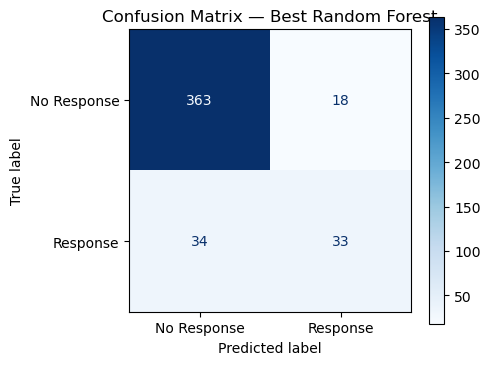

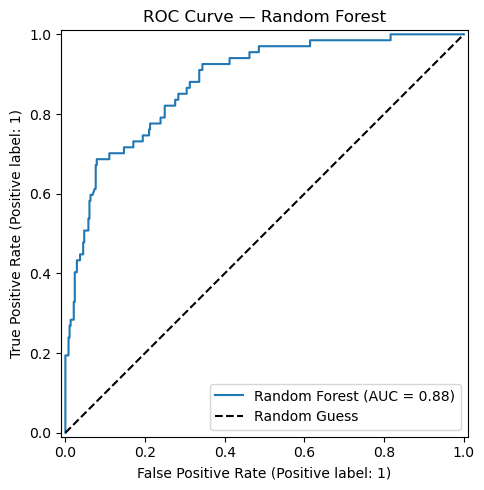

In [12]:
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

auc_rf   = roc_auc_score(y_test, y_prob_best)
prec_rf  = precision_score(y_test, y_pred_best)
rec_rf   = recall_score(y_test, y_pred_best)
f1_rf    = f1_score(y_test, y_pred_best)
acc_rf   = accuracy_score(y_test, y_pred_best)

print(f"ROC-AUC    : {auc_rf:.4f}   ")
print(f"Precision  : {prec_rf:.4f}")
print(f"Recall     : {rec_rf:.4f}   ")
print(f"F1-Score   : {f1_rf:.4f}")
print(f"Accuracy   : {acc_rf:.4f}  ")
print("\nFull classification report:")
print(classification_report(y_test, y_pred_best, target_names=['No Response', 'Response']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — Best Random Forest")
plt.tight_layout()
plt.show()

# ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title("ROC Curve — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()


The tuned Random Forest achieves a **ROC-AUC** of approximately **0.88**, indicating strong ability to distinguish between customers who respond to the campaign and those who do not.

Looking at the classification metrics, the model achieves **precision** of **0.62** and **recall** of **0.54** for the responding class. This suggests that while the model identifies a meaningful portion of responders, some potential responders are still missed, which is expected given the class imbalance in the dataset.

The **confusion matrix** shows that the model correctly classifies most non-responding customers, while also identifying a substantial number of actual responders. Overall, the results indicate that the model provides a useful balance between identifying likely responders and avoiding excessive false positives.

The ROC curve further confirms strong discrimination performance, with the model clearly outperforming the random baseline.

### 3.5 Threshold Tuning

In marketing applications, it is often **more costly to miss a potential buyer (false negative)** than to contact a customer who ultimately does not purchase (false positive).

To explore this trade-off, we evaluate model performance under several probability thresholds. Lower thresholds increase recall by identifying a larger share of potential responders, while higher thresholds improve precision by reducing false positives.

 Threshold  Precision  Recall     F1  Positives predicted
       0.2     0.3295  0.8507 0.4750                  173
       0.3     0.4364  0.7164 0.5424                  110
       0.4     0.5476  0.6866 0.6093                   84
       0.5     0.6471  0.4925 0.5593                   51


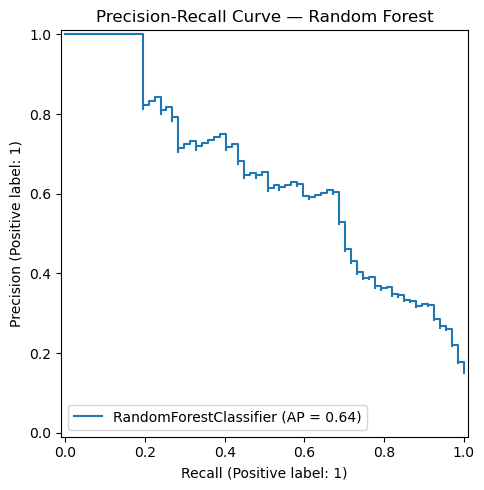

In [13]:
thresholds = [0.2, 0.3, 0.4, 0.5]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, y_pred_t), 4),
        'Recall':    round(recall_score(y_test, y_pred_t), 4),
        'F1':        round(f1_score(y_test, y_pred_t), 4),
        'Positives predicted': y_pred_t.sum()
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_estimator(best_rf, X_test, y_test, ax=ax)
ax.set_title("Precision-Recall Curve — Random Forest")
plt.tight_layout()
plt.show()

For marketing campaigns we recommend a threshold of 0.3. A higher Recall means fewer missed buyers (lower false negatives).


Classification report at threshold = 0.3:
              precision    recall  f1-score   support

 No Response       0.94      0.84      0.89       381
    Response       0.44      0.72      0.54        67

    accuracy                           0.82       448
   macro avg       0.69      0.78      0.71       448
weighted avg       0.87      0.82      0.84       448



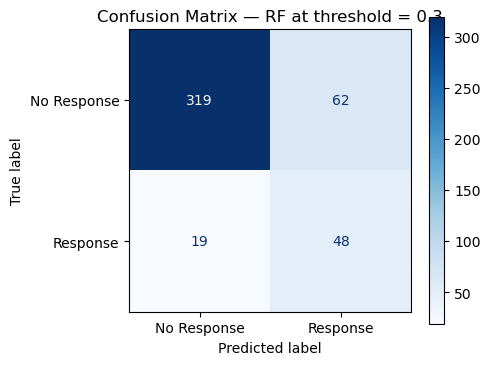

In [14]:
# Apply recommended threshold = 0.3
threshold = 0.3
y_pred_03 = (y_prob_best >= threshold).astype(int)

print(f"\nClassification report at threshold = {threshold}:")
print(classification_report(y_test, y_pred_03, target_names=['No Response', 'Response']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_03,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — RF at threshold = {threshold}")
plt.tight_layout()
plt.show()

Based on the results, we select **0.3 as the operational threshold**. This setting captures a larger share of potential responders while maintaining a reasonable level of precision, which aligns with the campaign objective of minimising missed buyers.

### 3.6 Learning Curves

Learning curves show how model performance changes as the amount of training data increases. They allow us to assess whether the model is suffering from **overfitting or underfitting**, and whether additional training data could improve performance.

- If the training score is much higher than the validation score, the model may be **overfitting**.
- If both scores are low, the model may be **underfitting**.

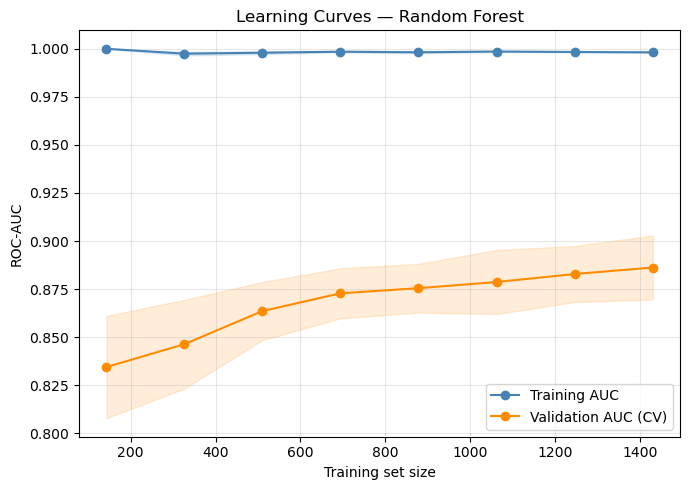

In [15]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The learning curves show that the **training AUC** remains very high, while the **validation AUC** gradually increases as more training data is used. The gap between the training and validation scores indicates that the model fits the training data extremely well, while its performance on unseen data is slightly lower.

However, the steady improvement in validation performance suggests that the **model continues to benefit from additional training data**. Overall, the model captures meaningful patterns in the data while still leaving some room for improvement in generalisation.

**proposed change Vanessa**

The learning curves reveal a clear overfitting problem. While the validation AUC improves gradually from ~0.835 to ~0.885 as more training data is added, the training AUC remains near-perfect at ~0.999 throughout leaving a persistent gap of ~0.11 that never closes. This indicates the model is memorising training data rather than learning generalisable patterns. Regularisation is required. Constraining max_depth, min_samples_leaf, and min_samples_split should narrow this gap and produce a more reliable model in production.

### 3.7 Feature importance

To understand which variables contribute most to the model’s predictions, we examine the feature importance scores produced by the Random Forest model. These scores measure the **mean decrease in impurity (Gini)**, indicating how much each feature helps reduce classification error across the trees in the forest.

Higher values indicate features that play a larger role in the model’s decision-making process.

Top 15 features by RF importance:
Total_Accepted_Campaigns    0.151669
Recency                     0.149578
Customer_Tenure             0.146018
Total_Spending              0.119843
Income                      0.104538
Total_Purchases             0.060462
Age                         0.058624
NumWebVisitsMonth           0.055621
NumDealsPurchases           0.032659
Teenhome                    0.031604
Marital_Status_Married      0.014504
Education_PhD               0.014329
Marital_Status_Together     0.013394
Marital_Status_Single       0.012330
Kidhome                     0.011728


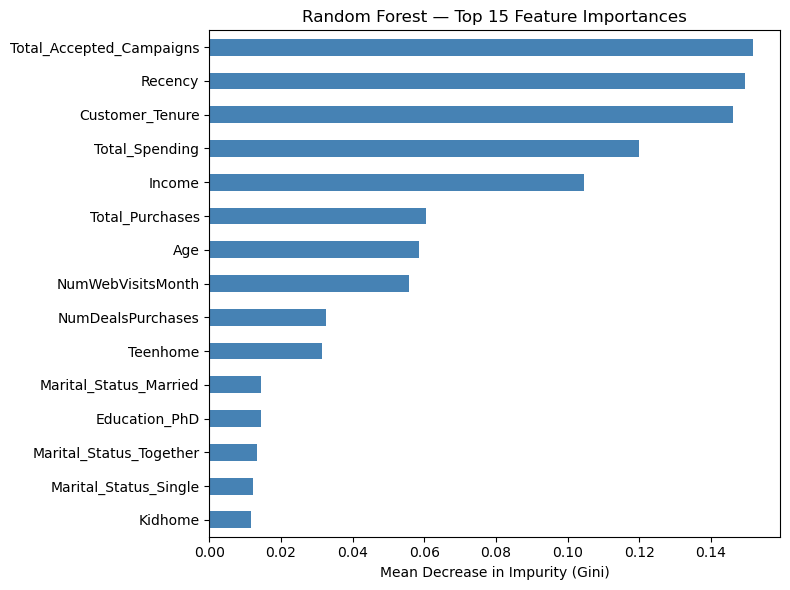

In [16]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features by RF importance:")
print(importances.head(15).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel("Mean Decrease in Impurity (Gini)")
ax.set_title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

The feature importance results indicate that `Total_Accepted_Campaigns`, `Recency`, and `Customer_Tenure` are the most influential predictors of campaign response. These variables reflect prior engagement with marketing campaigns and the recency of customer activity, suggesting that customers who have interacted with campaigns before and have been active more recently are more likely to respond.

Spending and purchasing behaviour variables, including `Total_Spending`, `Income`, and `Total_Purchases`, also contribute meaningfully to the model’s predictions. In contrast, demographic features such as `Education` and `Marital_Status` appear lower in the importance ranking within this model.

### 3.8 Permutation importance

To obtain a more robust measure of feature importance, we compute permutation importance on the test set. This method evaluates the contribution of each feature by randomly shuffling its values and measuring the resulting drop in model performance.

If shuffling a feature leads to a large decrease in ROC-AUC, it indicates that the feature plays an important role in the model’s predictions.

Top 15 features by Permutation Importance (on test set):
                 feature  importance_mean  importance_std
                 Recency         0.076721        0.011857
Total_Accepted_Campaigns         0.075050        0.014662
         Customer_Tenure         0.033484        0.009722
          Total_Spending         0.025260        0.009915
       NumWebVisitsMonth         0.010401        0.005894
                Teenhome         0.008849        0.008639
 Marital_Status_Together         0.004194        0.003010
  Marital_Status_Married         0.003837        0.002158
                  Income         0.002940        0.003783
   Marital_Status_Single         0.002683        0.001575
       NumDealsPurchases         0.001702        0.002316
                 Kidhome         0.001344        0.001374
         Education_Basic         0.000744        0.000203
           Education_PhD         0.000270        0.001767
         Total_Purchases         0.000225        0.004704


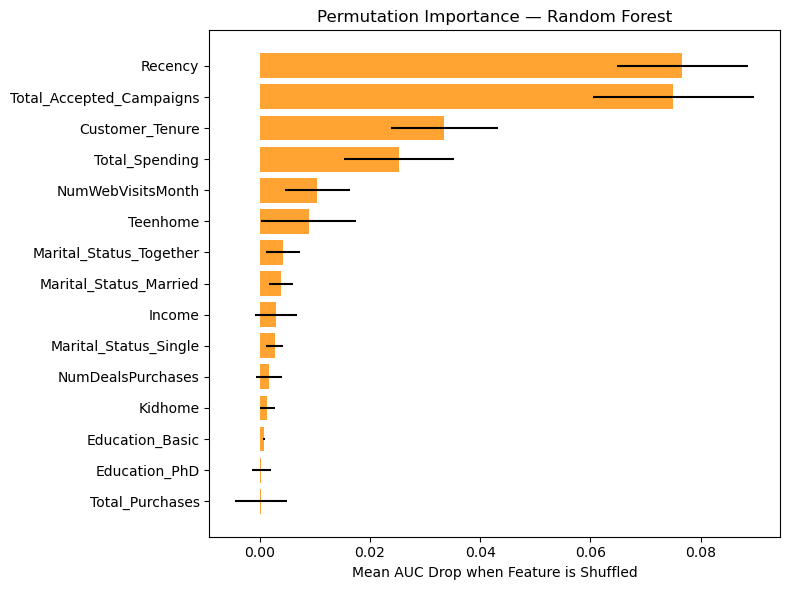

In [17]:
perm_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df = pd.DataFrame({
    'feature':          X_train.columns,
    'importance_mean':  perm_result.importances_mean,
    'importance_std':   perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("Top 15 features by Permutation Importance (on test set):")
print(perm_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top_perm = perm_df.head(15).sort_values('importance_mean')
ax.barh(top_perm['feature'], top_perm['importance_mean'],
        xerr=top_perm['importance_std'], color='darkorange', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Random Forest")
plt.tight_layout()
plt.show()

The permutation importance results show that `Recency` and `Total_Accepted_Campaigns` have the **largest impact on model performance**, as shuffling these variables produces the greatest drop in AUC. This suggests that recent customer activity and prior engagement with marketing campaigns are key signals for predicting response.

Other variables related to customer activity and engagement also contribute to the model’s predictions, although to a lesser extent.

### 3.9 SHAP values

To further interpret the model, we compute SHAP (SHapley Additive exPlanations) values. SHAP quantifies how each feature contributes to the model’s prediction by measuring how much it increases or decreases the predicted probability relative to a baseline.

SHAP values provide both **global explanations** (which features are most influential overall) and **local explanations** (how individual features influence a specific prediction).

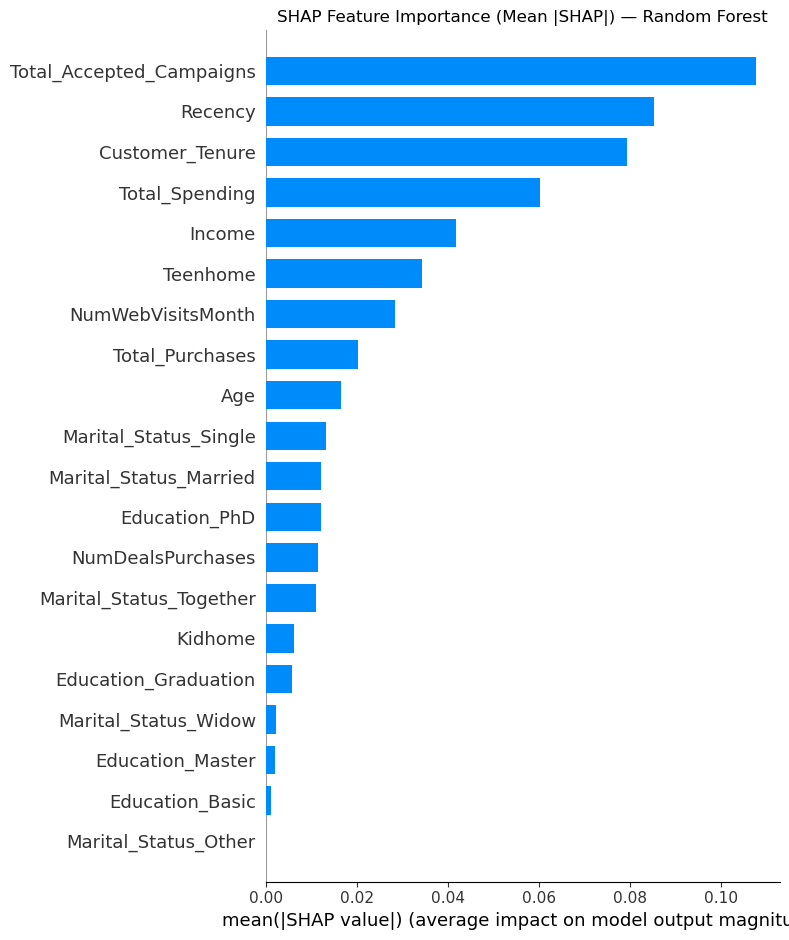

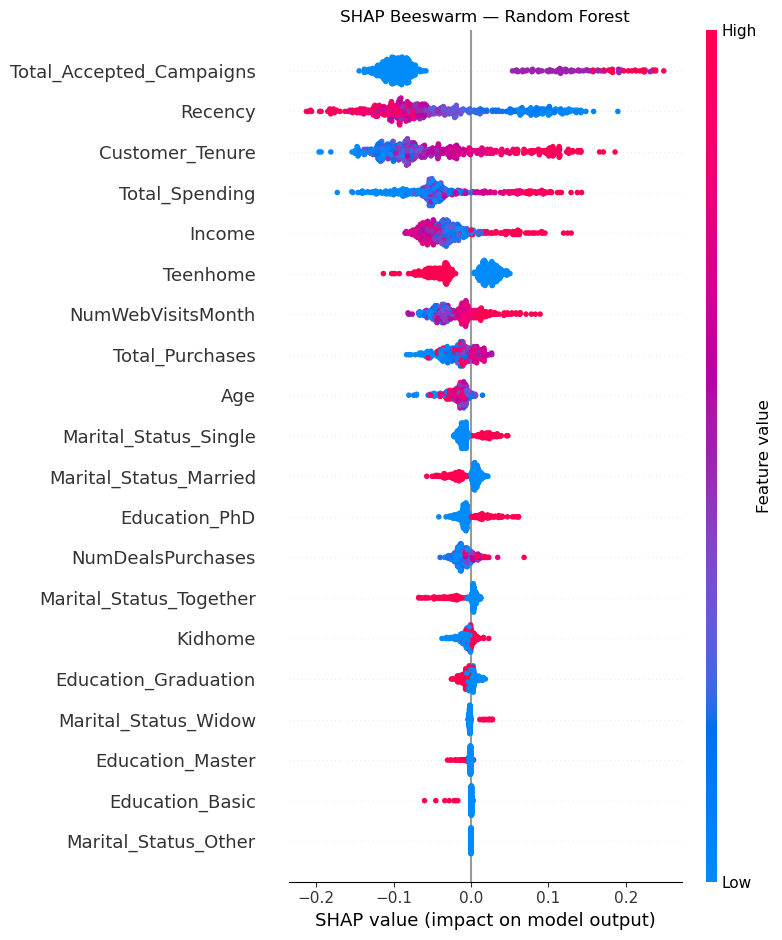

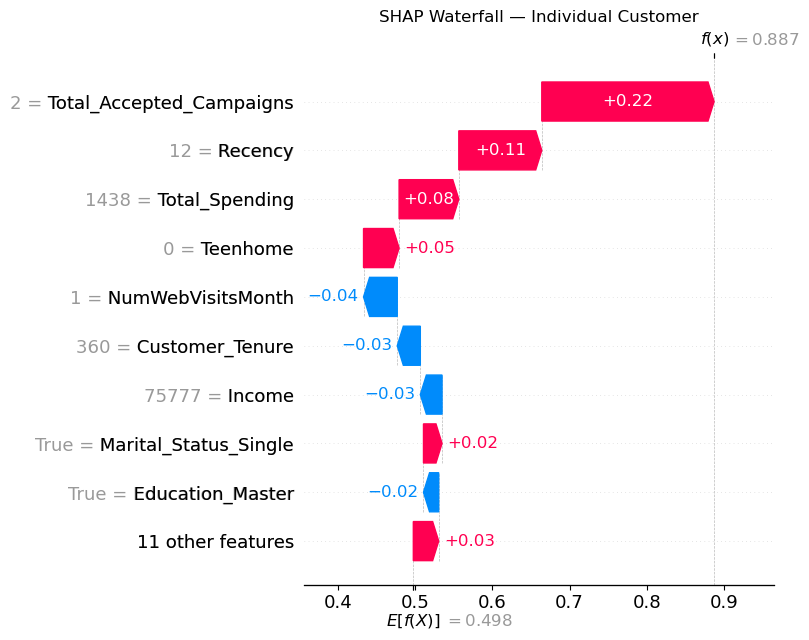

Customer predicted probability: 0.887


In [18]:
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# shap_values is a list [class_0_vals, class_1_vals] for binary RF
# Use index 1 for the positive class (Response = 1)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# Global summary: bar chart (average absolute SHAP)
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Random Forest")
plt.tight_layout()
plt.show()

# Global beeswarm: shows direction + magnitude of each feature
shap.summary_plot(sv, X_test, show=False)
plt.title("SHAP Beeswarm — Random Forest")
plt.tight_layout()
plt.show()

# Local explanation: explain one individual prediction
top_idx  = np.argmax(y_prob_best)
single_x = X_test.iloc[[top_idx]]

sv_raw = explainer.shap_values(single_x)

# SHAP >= 0.45 returns a 3D array (n_samples, n_features, n_classes)
# SHAP <  0.45 returns a list [class_0_array, class_1_array]
if isinstance(sv_raw, list):
    sv_single    = sv_raw[1][0]           # old API
    base_value   = explainer.expected_value[1]
else:
    sv_single    = sv_raw[0, :, 1]        # new API
    base_value   = explainer.expected_value[1]

shap.waterfall_plot(
    shap.Explanation(
        values        = sv_single,
        base_values   = base_value,
        data          = single_x.values[0],
        feature_names = X_test.columns.tolist()
    ),
    show=False
)
plt.title("SHAP Waterfall — Individual Customer")
plt.tight_layout()
plt.show()
print(f"Customer predicted probability: {y_prob_best[top_idx]:.3f}")

The SHAP analysis provides a detailed view of how different features influence the model’s predictions. Consistent with the previous feature importance analyses, variables related to **customer engagement and recent activity show the strongest impact on predicted campaign response**. In particular, **past campaign acceptance, recency of interaction, and customer tenure** appear among the **most influential** factors driving the model’s predictions.

The distribution of SHAP values also illustrates how different feature values affect the prediction. Higher levels of engagement or spending tend to push predictions toward a higher probability of response, while lower activity levels generally decrease the predicted likelihood of responding.

Finally, the individual SHAP explanation highlights how multiple features combine to influence a single prediction. In the example shown, factors such as **prior campaign acceptance, recent activity, and spending behaviour** contribute **positively** to the **predicted response probability** for the selected customer.

## 4. Full Model - XGBoost

In this section, we train an XGBoost model, a gradient boosting approach that builds trees sequentially, allowing the model to refine its predictions at each step. Including this model allows us to compare three different approaches, *Logistic Regression*, *Random Forest*, and *Gradient Boosting*, and **assess whether a boosting method can improve predictive performance**.

In [19]:
# scale_pos_weight handles class imbalance in XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale     = neg_count / pos_count
print(f"scale_pos_weight = {scale:.2f}  (neg/pos ratio for class balance)")

param_dist_xgb = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_lambda':        [10, 20, 50],
    'reg_alpha':         [0.05, 1, 2],
    'min_child_weight':  [20, 30, 50],
    'scale_pos_weight':  [neg_count / pos_count],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='auc', random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=100,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_, xgb_search.best_score_)

best_xgb = cast(XGBClassifier, xgb_search.best_estimator_)

y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_xgb.predict(X_test)

print(f"XGBoost — ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"XGBoost — Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost — F1       : {f1_score(y_test, y_pred_xgb):.4f}")

scale_pos_weight = 5.70  (neg/pos ratio for class balance)
Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'colsample_bytree': np.float64(0.6377771843023713), 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 20, 'n_estimators': 189, 'reg_alpha': 0.05, 'reg_lambda': 20, 'scale_pos_weight': np.float64(5.696629213483146), 'subsample': np.float64(0.8726454675891159)} 0.8898330312584225
XGBoost — ROC-AUC  : 0.8723
XGBoost — Recall   : 0.7015
XGBoost — F1       : 0.5839


The XGBoost model achieves a R**OC-AUC of approximately 0.83**, indicating good ability to distinguish between responding and non-responding customers. However, its overall ranking performance is slightly lower than the Random Forest model observed earlier.

At the same time, the model achieves a **higher recall**, suggesting that it is able to identify a meaningful share of potential responders, which is particularly relevant in marketing contexts where missing potential buyers can be costly. This reflects a trade-off between overall ranking performance and the ability to capture positive cases.

## 5. Model Comparison

MODEL COMPARISON TABLE
            ROC-AUC  Precision  Recall  F1-Score  Accuracy
Model                                                     
LR  — Full   0.8795     0.4113  0.7612    0.5340    0.8013
RF  — Full   0.8792     0.6471  0.4925    0.5593    0.8839
XGB — Full   0.8723     0.5000  0.7015    0.5839    0.8504

Best model by ROC-AUC : LR  — Full
AUC                   : 0.8795


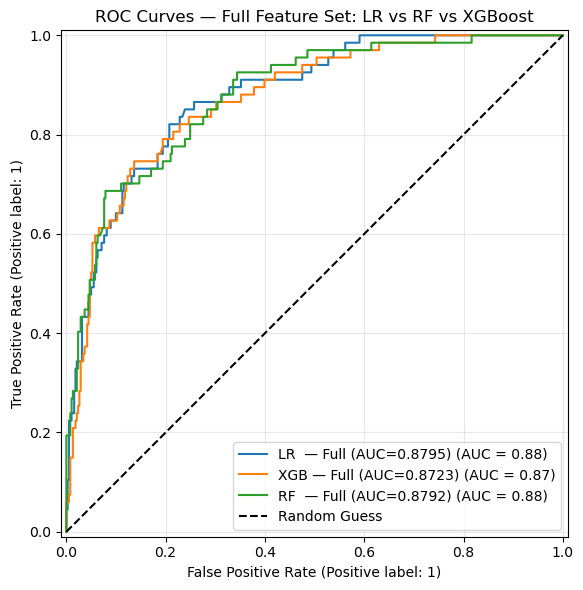

In [20]:
def evaluate_model(model, X_te, y_te, model_name):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)
    return {
        'Model':     model_name,
        'ROC-AUC':   round(roc_auc_score(y_te, y_prob), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1-Score':  round(f1_score(y_te, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        '_prob':     y_prob
    }

results = []

# Logistic Regression — Full feature set
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
results.append(evaluate_model(lr_pipe, X_test, y_test, 'LR  — Full'))

# XGBoost — Full feature set
results.append(evaluate_model(xgb_search.best_estimator_, X_test, y_test, 'XGB — Full'))

# Random Forest — Full feature set
results.append(evaluate_model(best_rf, X_test, y_test, 'RF  — Full'))

# Build and display comparison table
comparison_df = (
    pd.DataFrame(results)
    .drop(columns='_prob')
    .set_index('Model')
    .sort_index()
)
print('MODEL COMPARISON TABLE')
print(comparison_df.to_string())

best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f'\nBest model by ROC-AUC : {best_model_name}')
print(f'AUC                   : {comparison_df.loc[best_model_name, "ROC-AUC"]}')

# ROC curves: all three full-dataset models
fig, ax = plt.subplots(figsize=(8, 6))
for entry in results:
    RocCurveDisplay.from_predictions(
        y_test, entry['_prob'],
        ax=ax, name=f"{entry['Model']} (AUC={entry['ROC-AUC']})"
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title('ROC Curves — Full Feature Set: LR vs RF vs XGBoost')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The comparison across all models shows that the **XGBoost full model achieves the highest ROC-AUC (≈0.884)**, indicating the strongest overall ability to distinguish between responding and non-responding customers. Random Forest and Logistic Regression perform similarly on the full feature set, though slightly below the boosted model.

Considering the other metrics, the models display different trade-offs between precision and recall. Logistic Regression tends to achieve higher recall, identifying a larger share of potential responders, while Random Forest and XGBoost provide a more balanced performance reflected in their F1-scores. Given the marketing objective of minimising missed buyers, recall remains an important consideration when selecting the operational decision threshold.

However, while Logistic Regression achieves the highest recall,, the XGBoost full model provides the strongest overall ranking performance as measured by ROC-AUC, having still a better recall than Random Forest. Given that the campaign targeting process relies on ranking customers by predicted probability, the **XGBoost model represents the most suitable overall choice**.

#comment Vanessa pls review

Across feature sets, models using the full feature set consistently outperform those relying only on demographic variables, while behavioural-only models retain most of the predictive power. This indicates that customer engagement and purchasing behaviour capture the majority of the signal needed to predict campaign response, whereas demographic characteristics alone provide more limited information.

## 8. Summary of Results